|<img style="float:left;" src="images/usherb_transp.gif" width=90% height=90%> |<big>Pierre Proulx, ing, professeur</big>|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|


### Problème 18B14, Difffusion et réaction dans un catalyseur poreux en forme de disque

<img src='images/Chap-18-Prob18B14.png'>

Voir les hypothèses dans le livre de Transport Phenomena.


In [1]:
#
# Pierre Proulx
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline

In [2]:
# Paramètres, variables et fonctions
z,delta_z,R,k_1,a,D_A,C_AS,b=sp.symbols('z,delta_z,R,k_1,a,D_A,C_AS,b')                                                            
N_A=sp.Function('N_A')
C_A=sp.Function('C_A')(z)   

In [3]:
#
# Bilan sur une section d'épaisseur dz
#
S=sp.pi*R**2
eq=sp.Eq((S*N_A(z)-S*N_A(z+delta_z))/delta_z-k_1*a*C_A*S,0)
display(eq)

In [4]:
eq=sp.limit(eq.lhs,delta_z,0).doit()
display(eq)

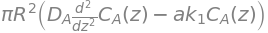

In [5]:
fick=-D_A*sp.diff(C_A,z)
eq=eq.subs(N_A(z),fick)
display(eq.simplify())
C_A=sp.dsolve(eq)
display(C_A)

In [6]:
#
# Solution
#
display(C_A)

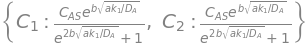

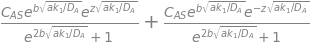

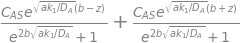

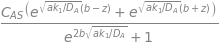

In [15]:
grad=sp.diff(C_A,z)
cl1=sp.Eq(grad.subs(z,0),0)
cl2=sp.Eq(C_A.subs(z,b)-C_AS,0)
display(cl1)
constantes=sp.solve((cl1,cl2),sp.symbols('C1,C2'))
display(constantes)
C_A=C_A.subs(constantes)
display(C_A)                                       # La solution est complète ici, on essaie
C_A=sp.powsimp(C_A)                                # de la mettre sous une forme plus compacte
display(C_A)                                       # mais ce n'est qu'esthétique
C_A=sp.simplify(C_A)
display(C_A)

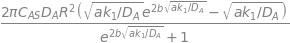

différence en pourcentage entre les deux résultats  -1.76704901671114e-12


In [16]:
#
# flux molaire * surface = taux de consommation dans le catalyseur
#
surface=R**2*2                  # *2 faces disque mince on néglige les côtés
taux=sp.pi*D_A*sp.diff(C_A,z).subs(z,b)*surface
display(taux)
#
# Afin de comparer avec la réponse donnée dans Transport Phenomena, on utilise des valeurs numériques
#
dico={'C_AS':1,'D_A':1.e-7,'a':1,'R':0.02,'b':0.001,'k_1':1e-7}
taux=taux.subs(dico)                                # notre résultat                                      
lam=sp.sqrt(k_1*a/D_A)
tauxBird=sp.pi*2*R**2*C_AS*D_A*lam*sp.tanh(lam*b)   # equation 18B.14-2
print('différence en pourcentage entre les deux résultats ', (tauxBird.subs(dico)- taux)/taux*100 )
